# Tutorial Computer Vision MKA
## Pengujian Klaim YOLO pada Objek Kecil dan Berkelompok

**Rujukan utama:**  
J. Redmon, S. Divvala, R. Girshick, and A. Farhadi,  
*You Only Look Once: Unified, Real-Time Object Detection*, CVPR, 2016.

**Topik:** Opsi C — YOLO  
**Dataset:** VisDrone2019-DET (dataset publik dengan objek berukuran kecil dan berkelompok)  
**Model:** Ultralytics YOLO11n  
**Intervensi:** Peningkatan resolusi input dari 640×640 menjadi 1280×1280  

### Tujuan Eksperimen

Notebook ini menguji klaim pada paper YOLO (2016) bahwa model YOLO mengalami kesulitan dalam mendeteksi **objek kecil yang muncul secara berkelompok**, seperti sekumpulan burung.

Eksperimen dilakukan untuk menjawab dua pertanyaan:

1. Apakah keterbatasan dalam mendeteksi objek kecil dan berkelompok masih terlihat pada model YOLO modern, yaitu YOLO11n?
2. Apakah peningkatan resolusi input dari 640×640 menjadi 1280×1280 dapat meningkatkan performa deteksi, khususnya pada objek kecil?

Eksperimen mencakup **baseline, intervensi resolusi, evaluasi mAP@0.5 dan mAP@0.5:0.95, analisis berdasarkan ukuran objek, serta pemeriksaan kasus kegagalan**.

# SETUP ENVIRONMENT

In [ ]:
!pip -q install -U ultralytics pandas matplotlib seaborn pyyaml opencv-python pycocotools

import os
import random
import json
import time
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import yaml
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 117.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 118.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 9.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.
dask-cudf-cu13 26.6.0 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6 which is incompatible.
cudf-cu13 26.6.0 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6 which is

## Konfigurasi Eksperimen

Eksperimen membandingkan dua konfigurasi YOLO11n dengan perbedaan pada resolusi input:

- **Baseline:** 640×640
- **Intervensi:** 1280×1280

Kedua konfigurasi menggunakan dataset, seed, dan jumlah epoch yang sama. Variabel utama yang diubah adalah `imgsz`.

In [ ]:
FAST_MODE = False

MODEL_NAME = "yolo11n.pt"

if FAST_MODE:
    EPOCHS = 3
    FRACTION = 0.15
    BATCH_640 = 16
    BATCH_1280 = 4
    MAX_SIZE_AP_IMAGES = 150
else:
    EPOCHS = 10
    FRACTION = 1.0
    BATCH_640 = 16
    BATCH_1280 = 4
    MAX_SIZE_AP_IMAGES = None

IMG_BASELINE = 640
IMG_HIGHRES = 1280

PROJECT_DIR = Path("/content/yolo_visdrone_experiment")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

print({
    "mode": "SMOKE TEST" if FAST_MODE else "FINAL EXPERIMENT",
    "model": MODEL_NAME,
    "epochs": EPOCHS,
    "fraction": FRACTION,
    "baseline_imgsz": IMG_BASELINE,
    "highres_imgsz": IMG_HIGHRES,
    "sizewise_max_images": MAX_SIZE_AP_IMAGES,
    "seed": SEED
})

if FAST_MODE:
    print("\nPERINGATAN: FAST_MODE=True hanya untuk menguji notebook.")
    print("Sebelum mengambil angka final untuk laporan, ubah FAST_MODE=False lalu Run All.")


{'mode': 'FINAL EXPERIMENT', 'model': 'yolo11n.pt', 'epochs': 10, 'fraction': 1.0, 'baseline_imgsz': 640, 'highres_imgsz': 1280, 'sizewise_max_images': None, 'seed': 42}


## Dataset Publik: VisDrone2019-DET

VisDrone2019-DET dipilih karena sesuai dengan fokus penelitian, yaitu objek kecil dan berkelompok pada citra udara.

Dataset mencakup 10 kelas objek, seperti `pedestrian`, `people`, `bicycle`, `car`, `van`, `truck`, `tricycle`, `awning-tricycle`, `bus`, dan `motor`.


In [ ]:
import os
import shutil
import zipfile
import urllib.request
from pathlib import Path
from PIL import Image

DATA_ROOT = Path("/content/VisDrone")
RAW_ROOT = Path("/content/visdrone_raw")
DATA_ROOT.mkdir(parents=True, exist_ok=True)
RAW_ROOT.mkdir(parents=True, exist_ok=True)

DOWNLOAD_URLS = {
    "train": "https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-train.zip",
    "val": "https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-val.zip",
}

def download_file(url, destination):
    destination = Path(destination)
    if destination.exists() and destination.stat().st_size > 10_000_000:
        print(f"Sudah tersedia: {destination}")
        return
    print(f"Mengunduh: {url}")
    urllib.request.urlretrieve(url, destination)
    print(f"Selesai: {destination} ({destination.stat().st_size/1e6:.1f} MB)")

def extract_zip(zip_path, extract_dir):
    marker = extract_dir / f"_EXTRACTED_{zip_path.name}"
    if marker.exists():
        print(f"Sudah diekstrak: {zip_path.name}")
        return
    print(f"Mengekstrak: {zip_path.name}")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)
    marker.touch()

def locate_raw_split(extract_dir, split_name):
    candidates = [
        extract_dir / f"VisDrone2019-DET-{split_name}",
        extract_dir,
    ]
    for c in candidates:
        if (c / "images").exists() and (c / "annotations").exists():
            return c
    raise FileNotFoundError(f"Folder raw VisDrone {split_name} tidak ditemukan di {extract_dir}")

def convert_visdrone_split(raw_split_dir, output_root, split_name):
    image_out = output_root / "images" / split_name
    label_out = output_root / "labels" / split_name
    image_out.mkdir(parents=True, exist_ok=True)
    label_out.mkdir(parents=True, exist_ok=True)

    image_files = sorted((raw_split_dir / "images").glob("*"))
    converted = 0

    for img_path in image_files:
        if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue

        dst_img = image_out / img_path.name
        if not dst_img.exists():
            shutil.copy2(img_path, dst_img)

        ann_path = raw_split_dir / "annotations" / f"{img_path.stem}.txt"
        label_path = label_out / f"{img_path.stem}.txt"

        if not ann_path.exists():
            label_path.write_text("")
            continue

        with Image.open(img_path) as im:
            W, H = im.size

        yolo_lines = []
        for row in ann_path.read_text(encoding="utf-8").splitlines():
            parts = row.strip().split(",")
            if len(parts) < 8:
                continue

            x, y, w, h = map(float, parts[:4])
            score = float(parts[4])
            category = int(parts[5])

            if category == 0 or category > 10:
                continue

            if score == 0:
                continue

            xc = (x + w / 2.0) / W
            yc = (y + h / 2.0) / H
            wn = w / W
            hn = h / H

            yolo_lines.append(
                f"{category-1} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}"
            )

        label_path.write_text("\n".join(yolo_lines), encoding="utf-8")
        converted += 1

    print(f"{split_name}: {converted} gambar dikonversi.")

for split, url in DOWNLOAD_URLS.items():
    zip_path = RAW_ROOT / Path(url).name
    download_file(url, zip_path)
    extract_zip(zip_path, RAW_ROOT)

    raw_dir = locate_raw_split(RAW_ROOT, split)
    convert_visdrone_split(raw_dir, DATA_ROOT, split)

CLASS_NAMES = [
    "pedestrian", "people", "bicycle", "car", "van",
    "truck", "tricycle", "awning-tricycle", "bus", "motor"
]

DATA_YAML = str(DATA_ROOT / "visdrone.yaml")
yaml_text = f"""path: {DATA_ROOT}
train: images/train
val: images/val

names:
"""
for i, name in enumerate(CLASS_NAMES):
    yaml_text += f"  {i}: {name}\n"

Path(DATA_YAML).write_text(yaml_text, encoding="utf-8")

print("\nDataset siap.")
print("DATA_ROOT:", DATA_ROOT)
print("DATA_YAML:", DATA_YAML)
print(Path(DATA_YAML).read_text())

Sudah tersedia: /content/visdrone_raw/VisDrone2019-DET-train.zip
Mengekstrak: VisDrone2019-DET-train.zip
train: 6471 gambar dikonversi.
Sudah tersedia: /content/visdrone_raw/VisDrone2019-DET-val.zip
Mengekstrak: VisDrone2019-DET-val.zip
val: 548 gambar dikonversi.

Dataset siap.
DATA_ROOT: /content/VisDrone
DATA_YAML: /content/VisDrone/visdrone.yaml
path: /content/VisDrone
train: images/train
val: images/val

names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor



### Validasi Struktur Dataset

Memastikan struktur dataset lengkap dan siap digunakan sebelum eksperimen dijalankan.

In [ ]:
required_dirs = [
    DATA_ROOT / "images" / "train",
    DATA_ROOT / "images" / "val",
    DATA_ROOT / "labels" / "train",
    DATA_ROOT / "labels" / "val",
]

for d in required_dirs:
    assert d.exists(), f"Folder tidak ditemukan: {d}"

train_images = list((DATA_ROOT / "images" / "train").glob("*.jpg"))
val_images = list((DATA_ROOT / "images" / "val").glob("*.jpg"))
train_labels = list((DATA_ROOT / "labels" / "train").glob("*.txt"))
val_labels = list((DATA_ROOT / "labels" / "val").glob("*.txt"))

assert len(train_images) > 0, "Training images kosong."
assert len(val_images) > 0, "Validation images kosong."
assert len(train_labels) > 0, "Training labels kosong."
assert len(val_labels) > 0, "Validation labels kosong."

dataset_root = DATA_ROOT

print(f"Train images : {len(train_images):,}")
print(f"Val images   : {len(val_images):,}")
print(f"Train labels : {len(train_labels):,}")
print(f"Val labels   : {len(val_labels):,}")
print("Struktur dataset valid.")


Train images : 6,471
Val images   : 548
Train labels : 6,471
Val labels   : 548
Struktur dataset valid.


## 6. EDA: Ukuran Objek

Ukuran objek dihitung dari bounding box pada anotasi YOLO. Untuk konsistensi analisis, kategori ukuran menggunakan batas luas ala COCO setelah bounding box dikembalikan ke ukuran piksel:

- **small:** area < 32² piksel
- **medium:** 32² ≤ area < 96² piksel
- **large:** area ≥ 96² piksel

Batas ini dipakai sebagai definisi analisis ukuran.


## OBJECT-SIZE EDA

VisDrone root: /content/VisDrone
size
large     0.055302
medium    0.339797
small     0.604901
Name: proportion, dtype: float64


,image,class_id,width_px,height_px,area_px2,size
0,0000002_00005_d_0000014,3,73.99968,32.99994,2441.98500,medium
1,0000002_00005_d_0000014,3,61.00032,45.99990,2806.00862,medium
2,0000002_00005_d_0000014,3,64.00032,50.99976,3264.00096,medium
3,0000002_00005_d_0000014,3,61.00032,37.99980,2317.99996,medium
4,0000002_00005_d_0000014,3,64.99968,32.99994,2144.98554,medium


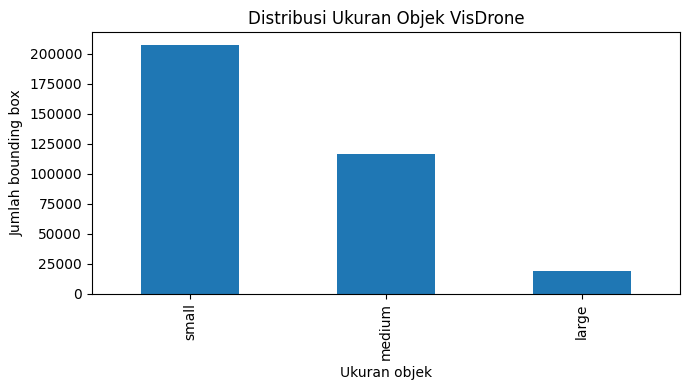

In [ ]:
from PIL import Image

def find_visdrone_root():
    roots = [
        Path("/content/datasets/VisDrone"),
        Path("/content/VisDrone"),
        Path("/root/.cache/ultralytics/datasets/VisDrone"),
    ]
    for r in roots:
        if (r / "images" / "train").exists():
            return r
    return None

dataset_root = find_visdrone_root()
print("VisDrone root:", dataset_root)

def yolo_label_sizes(label_dir, image_dir, max_files=None):
    records = []
    label_files = sorted(Path(label_dir).glob("*.txt"))
    if max_files:
        label_files = label_files[:max_files]

    for lf in label_files:
        img_path = None
        for ext in [".jpg", ".jpeg", ".png"]:
            p = Path(image_dir) / (lf.stem + ext)
            if p.exists():
                img_path = p
                break
        if img_path is None:
            continue

        with Image.open(img_path) as im:
            W, H = im.size

        for line in lf.read_text().splitlines():
            parts = line.split()
            if len(parts) != 5:
                continue
            cls, xc, yc, w, h = map(float, parts)
            bw, bh = w * W, h * H
            area = bw * bh
            if area < 32**2:
                size = "small"
            elif area < 96**2:
                size = "medium"
            else:
                size = "large"
            records.append({
                "image": lf.stem,
                "class_id": int(cls),
                "width_px": bw,
                "height_px": bh,
                "area_px2": area,
                "size": size
            })
    return pd.DataFrame(records)

if dataset_root is not None:
    train_size_df = yolo_label_sizes(
        dataset_root / "labels" / "train",
        dataset_root / "images" / "train",
        max_files=1000 if FAST_MODE else None
    )
    print(train_size_df["size"].value_counts(normalize=True).sort_index())
    display(train_size_df.head())

    plt.figure(figsize=(7,4))
    train_size_df["size"].value_counts().reindex(["small","medium","large"]).plot(kind="bar")
    plt.title("Distribusi Ukuran Objek VisDrone")
    plt.xlabel("Ukuran objek")
    plt.ylabel("Jumlah bounding box")
    plt.tight_layout()
    plt.show()
else:
    print("Dataset belum ditemukan. Jalankan cell training agar VisDrone diunduh otomatis.")


## Persamaan Inti dari Paper

Paper mendefinisikan confidence YOLO sebagai:

**Confidence = Pr(Object) × IoU(pred, truth)**

Pada tahap inferensi, confidence kelas diperoleh dengan mengalikan probabilitas kelas bersyarat dengan confidence box.

Di bawah ini IoU diimplementasikan eksplisit untuk menunjukkan pemahaman terhadap komponen inti deteksi, walaupun model yang dilatih adalah YOLO modern.


In [ ]:
def xyxy_iou(box_a, box_b):
    # box = [x1, y1, x2, y2]
    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b

    inter_x1 = max(xa1, xb1)
    inter_y1 = max(ya1, yb1)
    inter_x2 = min(xa2, xb2)
    inter_y2 = min(ya2, yb2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, xa2 - xa1) * max(0.0, ya2 - ya1)
    area_b = max(0.0, xb2 - xb1) * max(0.0, yb2 - yb1)
    union = area_a + area_b - inter_area

    return inter_area / union if union > 0 else 0.0

example_iou = xyxy_iou([0,0,10,10], [5,5,15,15])
print("Contoh IoU:", example_iou)


Contoh IoU: 0.14285714285714285


## Baseline — YOLO11n pada 640×640

Baseline menggunakan YOLO11n pretrained dan fine-tuning pada VisDrone. Pengaturan lain dibuat sama dengan eksperimen resolusi tinggi.

Paper asli menggunakan satu jaringan untuk memprediksi bounding box dan kelas secara end-to-end. Eksperimen modern ini mempertahankan prinsip unified detector, tetapi menggunakan implementasi YOLO modern.


In [ ]:
from ultralytics import YOLO
import time, os

baseline_model = YOLO(MODEL_NAME)

t0 = time.time()
baseline_train = baseline_model.train(
    data=DATA_YAML,
    imgsz=IMG_BASELINE,
    epochs=EPOCHS,
    batch=BATCH_640,
    fraction=FRACTION,
    seed=SEED,
    deterministic=True,
    pretrained=True,
    project=str(PROJECT_DIR),
    name="baseline_640",
    exist_ok=True,
    plots=True,
    verbose=True
)
baseline_train_time = time.time() - t0

print(f"Baseline training time: {baseline_train_time/60:.2f} minutes")


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/VisDrone/visdrone.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0,

## Evaluasi Baseline

Metrik wajib tugas:
- **mAP@0.5**
- **mAP@0.5:0.95**
- breakdown berdasarkan ukuran objek

Ultralytics menyediakan `results.box.map50` untuk mAP@0.5 dan `results.box.map` untuk mAP@0.5:0.95.

In [ ]:
baseline_best = PROJECT_DIR / "baseline_640" / "weights" / "best.pt"
baseline_model = YOLO(str(baseline_best))

t0 = time.time()
baseline_metrics = baseline_model.val(
    data=DATA_YAML,
    imgsz=IMG_BASELINE,
    split="val",
    batch=BATCH_640,
    plots=True,
    save_json=False,
    verbose=True
)
baseline_val_time = time.time() - t0

baseline_map50 = float(baseline_metrics.box.map50)
baseline_map5095 = float(baseline_metrics.box.map)

baseline_result = {
    "experiment": "YOLO11n-640",
    "imgsz": IMG_BASELINE,
    "mAP50": baseline_map50,
    "mAP50-95": baseline_map5095,
    "val_time_min": baseline_val_time / 60,
}
print(json.dumps(baseline_result, indent=2))


Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,584,102 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2999.6±501.1 MB/s, size: 150.7 KB)
val: Scanning /content/VisDrone/labels/val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 153.2Mit/s 0.0s
WARNING ⚠️ Dataset images contain up to 317 objects (val=317), but max_det=300. This mismatch can cap recall and produce invalid validation metrics. Raising it may increase validation cost but cannot increase model or export capacity, which may cap recall. Setting max_det=317 to match the observed maximum.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 2.2it/s 16.1s
                   all        548      38759      0.348      0.269      0.229      0.128
            pedestrian        520       8844      0.334       0.33      0.248     0.0977
  

## 10. Intervensi — Resolusi Input 1280×1280

Satu-satunya perubahan utama dari baseline adalah resolusi input. Hal ini langsung menguji apakah representasi spasial yang lebih tinggi membantu objek kecil.

**Kontrol eksperimen:** model, dataset, seed, epoch, fraction, dan parameter training dibuat sama sebisa mungkin. Batch diturunkan pada 1280 karena kebutuhan VRAM lebih tinggi.


In [ ]:
highres_model = YOLO(MODEL_NAME)

t0 = time.time()
highres_train = highres_model.train(
    data=DATA_YAML,
    imgsz=IMG_HIGHRES,
    epochs=EPOCHS,
    batch=BATCH_1280,
    fraction=FRACTION,
    seed=SEED,
    deterministic=True,
    pretrained=True,
    project=str(PROJECT_DIR),
    name="highres_1280",
    exist_ok=True,
    plots=True,
    verbose=True
)
highres_train_time = time.time() - t0

print(f"High-resolution training time: {highres_train_time/60:.2f} minutes")


Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/VisDrone/visdrone.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=highres_1280, nbs=64, nms=None, opset=None, optimize=False,

In [ ]:
# ============================================================
# 11. VALIDATE HIGH-RES
# ============================================================
highres_best = PROJECT_DIR / "highres_1280" / "weights" / "best.pt"
highres_model = YOLO(str(highres_best))

t0 = time.time()
highres_metrics = highres_model.val(
    data=DATA_YAML,
    imgsz=IMG_HIGHRES,
    split="val",
    batch=BATCH_1280,
    plots=True,
    save_json=False,
    verbose=True
)
highres_val_time = time.time() - t0

highres_map50 = float(highres_metrics.box.map50)
highres_map5095 = float(highres_metrics.box.map)

highres_result = {
    "experiment": "YOLO11n-1280",
    "imgsz": IMG_HIGHRES,
    "mAP50": highres_map50,
    "mAP50-95": highres_map5095,
    "val_time_min": highres_val_time / 60,
}
print(json.dumps(highres_result, indent=2))


Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,584,102 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2509.8±660.9 MB/s, size: 142.5 KB)
val: Scanning /content/VisDrone/labels/val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 176.8Mit/s 0.0s
WARNING ⚠️ Dataset images contain up to 317 objects (val=317), but max_det=300. This mismatch can cap recall and produce invalid validation metrics. Raising it may increase validation cost but cannot increase model or export capacity, which may cap recall. Setting max_det=317 to match the observed maximum.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 137/137 6.1it/s 22.4s
                   all        548      38759      0.492      0.396      0.379      0.228
            pedestrian        520       8844       0.51      0.496      0.479      0.229


## 12. Perbandingan Utama

Perubahan dihitung dari angka aktual hasil validasi.


,experiment,imgsz,mAP50,mAP50-95,val_time_min,delta_mAP50,delta_mAP50-95
0,YOLO11n-640,640,0.2287,0.1279,0.3258,0.0000,0.0000
1,YOLO11n-1280,1280,0.3792,0.2277,0.4340,0.1504,0.0997


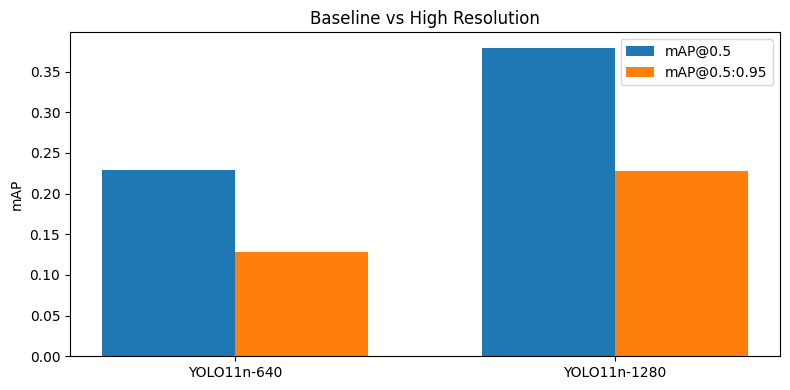

In [ ]:
results_df = pd.DataFrame([baseline_result, highres_result])
results_df["delta_mAP50"] = results_df["mAP50"] - results_df.loc[0, "mAP50"]
results_df["delta_mAP50-95"] = results_df["mAP50-95"] - results_df.loc[0, "mAP50-95"]

display(results_df.round(4))

plt.figure(figsize=(8,4))
x = np.arange(2)
width = 0.35
plt.bar(x-width/2, results_df["mAP50"], width, label="mAP@0.5")
plt.bar(x+width/2, results_df["mAP50-95"], width, label="mAP@0.5:0.95")
plt.xticks(x, results_df["experiment"])
plt.ylabel("mAP")
plt.title("Baseline vs High Resolution")
plt.legend()
plt.tight_layout()
plt.show()


## Breakdown mAP Berdasarkan Ukuran Objek

Evaluasi dilakukan berdasarkan tiga kategori ukuran objek, yaitu **small, medium, dan large**, sesuai dengan definisi area COCO:

- **Small:** area < 32²
- **Medium:** 32² ≤ area < 96²
- **Large:** area ≥ 96²

Evaluasi dilakukan untuk dua metrik:
1. **mAP@0.5**
2. **mAP@0.5:0.95**

Prediksi dan ground truth dikonversi ke format COCO untuk menghitung performa berdasarkan ukuran objek.

In [ ]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from PIL import Image

CLASS_NAMES = [
    "pedestrian", "people", "bicycle", "car", "van",
    "truck", "tricycle", "awning-tricycle", "bus", "motor"
]

def make_visdrone_coco_gt(dataset_root, split="val", max_images=None):
    dataset_root = Path(dataset_root)
    image_dir = dataset_root / "images" / split
    label_dir = dataset_root / "labels" / split

    image_files = sorted(image_dir.glob("*.jpg"))
    if max_images is not None:
        image_files = image_files[:max_images]

    images, annotations = [], []
    ann_id = 1

    for image_id, img_path in enumerate(image_files, start=1):
        with Image.open(img_path) as im:
            W, H = im.size

        images.append({
            "id": image_id,
            "file_name": img_path.name,
            "width": W,
            "height": H
        })

        label_path = label_dir / f"{img_path.stem}.txt"
        if not label_path.exists():
            continue

        for line in label_path.read_text().splitlines():
            p = line.split()
            if len(p) != 5:
                continue

            cls, xc, yc, w, h = map(float, p)
            bw, bh = w * W, h * H
            x = (xc * W) - bw / 2
            y = (yc * H) - bh / 2

            annotations.append({
                "id": ann_id,
                "image_id": image_id,
                "category_id": int(cls) + 1,
                "bbox": [x, y, bw, bh],
                "area": bw * bh,
                "iscrowd": 0
            })
            ann_id += 1

    gt = {
        "images": images,
        "annotations": annotations,
        "categories": [
            {"id": i+1, "name": n, "supercategory": "object"}
            for i, n in enumerate(CLASS_NAMES)
        ]
    }

    gt_path = PROJECT_DIR / f"visdrone_{split}_coco_gt.json"
    with open(gt_path, "w") as f:
        json.dump(gt, f)

    return gt_path, image_files

def predict_to_coco(model, image_files, imgsz):
    predictions = []

    for image_id, img_path in enumerate(image_files, start=1):
        results = model.predict(
            source=str(img_path),
            imgsz=imgsz,
            conf=0.001,
            iou=0.7,
            max_det=300,
            verbose=False
        )
        r = results[0]

        if r.boxes is None or len(r.boxes) == 0:
            continue

        boxes = r.boxes.xyxy.cpu().numpy()
        scores = r.boxes.conf.cpu().numpy()
        classes = r.boxes.cls.cpu().numpy().astype(int)

        for box, score, cls in zip(boxes, scores, classes):
            x1, y1, x2, y2 = box.tolist()
            predictions.append({
                "image_id": image_id,
                "category_id": int(cls) + 1,
                "bbox": [
                    x1,
                    y1,
                    max(0.0, x2-x1),
                    max(0.0, y2-y1)
                ],
                "score": float(score)
            })

    pred_path = PROJECT_DIR / f"pred_{imgsz}.json"
    with open(pred_path, "w") as f:
        json.dump(predictions, f)

    return pred_path

def coco_size_metrics(gt_path, pred_path, iou_thresholds):
    coco_gt = COCO(str(gt_path))
    coco_dt = coco_gt.loadRes(str(pred_path)) if Path(pred_path).stat().st_size > 2 else None

    if coco_dt is None:
        return {
            "mAP": np.nan,
            "mAP50": np.nan,
            "mAP_small": np.nan,
            "mAP_medium": np.nan,
            "mAP_large": np.nan
        }

    evaluator = COCOeval(coco_gt, coco_dt, "bbox")
    evaluator.params.iouThrs = np.array(iou_thresholds)
    evaluator.evaluate()
    evaluator.accumulate()
    evaluator.summarize()

    # stats:
    # [0] AP all, [1] AP50 all, [2] AP75 all,
    # [3] AP small, [4] AP medium, [5] AP large
    return {
        "mAP": float(evaluator.stats[0]),
        "mAP50": float(evaluator.stats[1]),
        "mAP_small": float(evaluator.stats[3]),
        "mAP_medium": float(evaluator.stats[4]),
        "mAP_large": float(evaluator.stats[5])
    }

if dataset_root is None:
    dataset_root = find_visdrone_root()

print("Jumlah gambar untuk size-wise mAP:", MAX_SIZE_AP_IMAGES or "seluruh validation set")

gt_path, eval_images = make_visdrone_coco_gt(
    dataset_root, "val", max_images=MAX_SIZE_AP_IMAGES
)

print("Ground truth COCO:", gt_path)
print("Jumlah gambar evaluasi:", len(eval_images))


Jumlah gambar untuk size-wise mAP: seluruh validation set
Ground truth COCO: /content/yolo_visdrone_experiment/visdrone_val_coco_gt.json
Jumlah gambar evaluasi: 548


In [ ]:
t0 = time.time()
baseline_pred_path = predict_to_coco(
    baseline_model, eval_images, IMG_BASELINE
)
baseline_size_time = time.time() - t0

t0 = time.time()
highres_pred_path = predict_to_coco(
    highres_model, eval_images, IMG_HIGHRES
)
highres_size_time = time.time() - t0

print("Prediction time baseline:", round(baseline_size_time/60, 2), "min")
print("Prediction time high-res:", round(highres_size_time/60, 2), "min")

# IoU = 0.50
baseline_ap50_size = coco_size_metrics(
    gt_path, baseline_pred_path, [0.50]
)
highres_ap50_size = coco_size_metrics(
    gt_path, highres_pred_path, [0.50]
)

# IoU = 0.50:0.95
baseline_ap5095_size = coco_size_metrics(
    gt_path, baseline_pred_path, np.arange(0.50, 0.96, 0.05)
)
highres_ap5095_size = coco_size_metrics(
    gt_path, highres_pred_path, np.arange(0.50, 0.96, 0.05)
)

size_map_df = pd.DataFrame([
    {
        "experiment": "YOLO11n-640",
        "mAP@0.5": baseline_ap50_size["mAP50"],
        "small": baseline_ap50_size["mAP_small"],
        "medium": baseline_ap50_size["mAP_medium"],
        "large": baseline_ap50_size["mAP_large"],
    },
    {
        "experiment": "YOLO11n-1280",
        "mAP@0.5": highres_ap50_size["mAP50"],
        "small": highres_ap50_size["mAP_small"],
        "medium": highres_ap50_size["mAP_medium"],
        "large": highres_ap50_size["mAP_large"],
    }
])

size_map_5095_df = pd.DataFrame([
    {
        "experiment": "YOLO11n-640",
        "mAP@0.5:0.95": baseline_ap5095_size["mAP"],
        "small": baseline_ap5095_size["mAP_small"],
        "medium": baseline_ap5095_size["mAP_medium"],
        "large": baseline_ap5095_size["mAP_large"],
    },
    {
        "experiment": "YOLO11n-1280",
        "mAP@0.5:0.95": highres_ap5095_size["mAP"],
        "small": highres_ap5095_size["mAP_small"],
        "medium": highres_ap5095_size["mAP_medium"],
        "large": highres_ap5095_size["mAP_large"],
    }
])

print("=== mAP@0.5 berdasarkan ukuran ===")
display(size_map_df.round(4))

print("=== mAP@0.5:0.95 berdasarkan ukuran ===")
display(size_map_5095_df.round(4))


Prediction time baseline: 0.21 min
Prediction time high-res: 0.27 min
loading annotations into memory...
Done (t=0.11s)
creating index...
index created!
Loading and preparing results...
DONE (t=1.12s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=5.67s).
Accumulating evaluation results...
DONE (t=0.37s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.203
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.203
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = 0.108
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.326
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.463
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.080
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 

,experiment,mAP@0.5,small,medium,large
0,YOLO11n-640,0.2031,0.1082,0.3264,0.463
1,YOLO11n-1280,0.3552,0.2490,0.5130,0.571


=== mAP@0.5:0.95 berdasarkan ukuran ===


,experiment,mAP@0.5:0.95,small,medium,large
0,YOLO11n-640,0.1176,0.0451,0.1911,0.3544
1,YOLO11n-1280,0.2155,0.1237,0.3308,0.4519


## Visualisasi Size-wise mAP

Grafik berikut menunjukkan perbandingan mAP berdasarkan ukuran objek pada resolusi 640×640 dan 1280×1280. Fokus utama diberikan pada kategori **small** sesuai dengan klaim yang diuji.

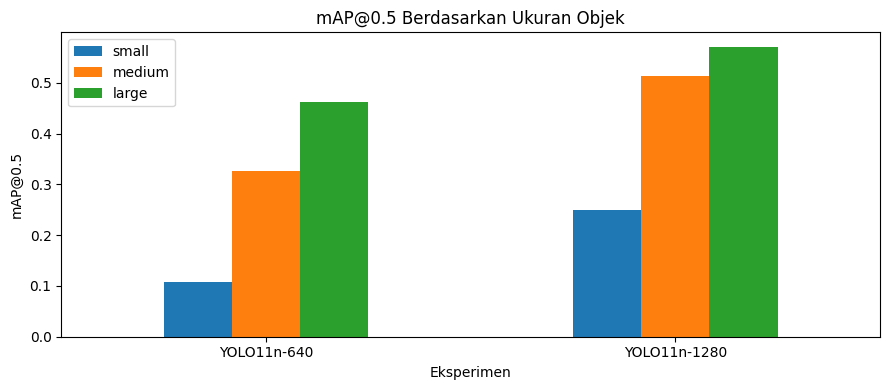

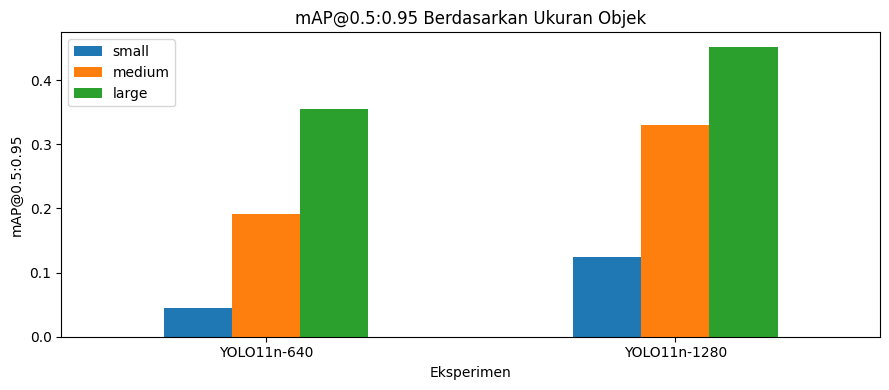

In [ ]:
fig = size_map_df.set_index("experiment")[["small","medium","large"]].plot(
    kind="bar", figsize=(9,4)
)
plt.ylabel("mAP@0.5")
plt.xlabel("Eksperimen")
plt.title("mAP@0.5 Berdasarkan Ukuran Objek")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

fig = size_map_5095_df.set_index("experiment")[["small","medium","large"]].plot(
    kind="bar", figsize=(9,4)
)
plt.ylabel("mAP@0.5:0.95")
plt.xlabel("Eksperimen")
plt.title("mAP@0.5:0.95 Berdasarkan Ukuran Objek")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
delta_size = size_map_5095_df.set_index("experiment")[["small","medium","large"]].copy()
delta_size.loc["Delta (1280-640)"] = (
    delta_size.loc["YOLO11n-1280"] - delta_size.loc["YOLO11n-640"]
)
display(delta_size.round(4))


,small,medium,large
experiment,,,
YOLO11n-640,0.0451,0.1911,0.3544
YOLO11n-1280,0.1237,0.3308,0.4519
Delta (1280-640),0.0786,0.1397,0.0975


## Kurva Training



Training curve: baseline_640


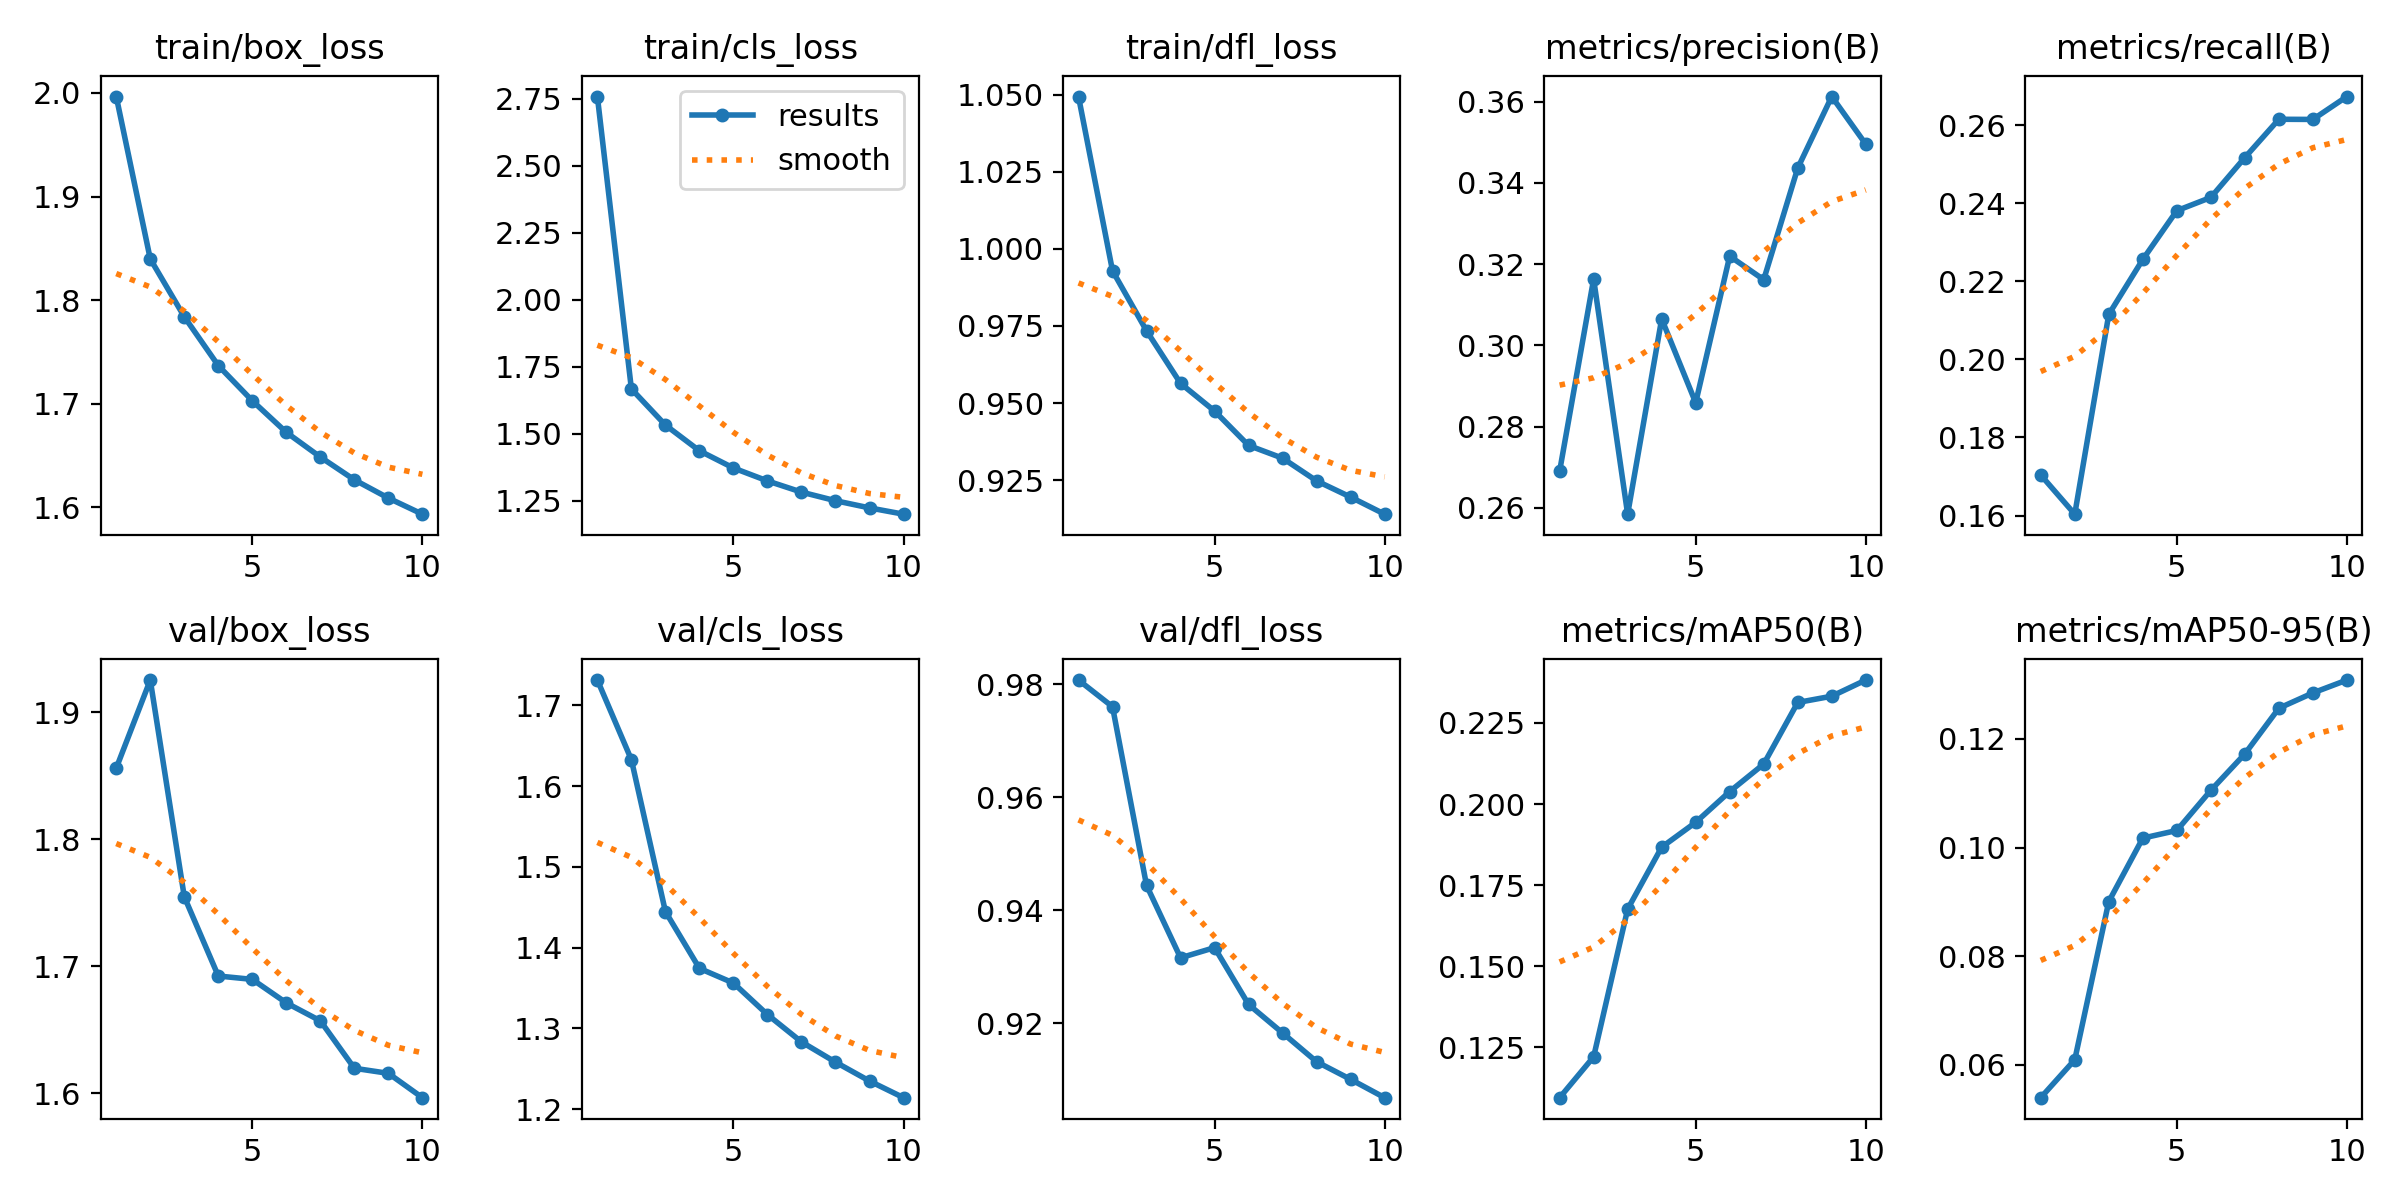

Training curve: highres_1280


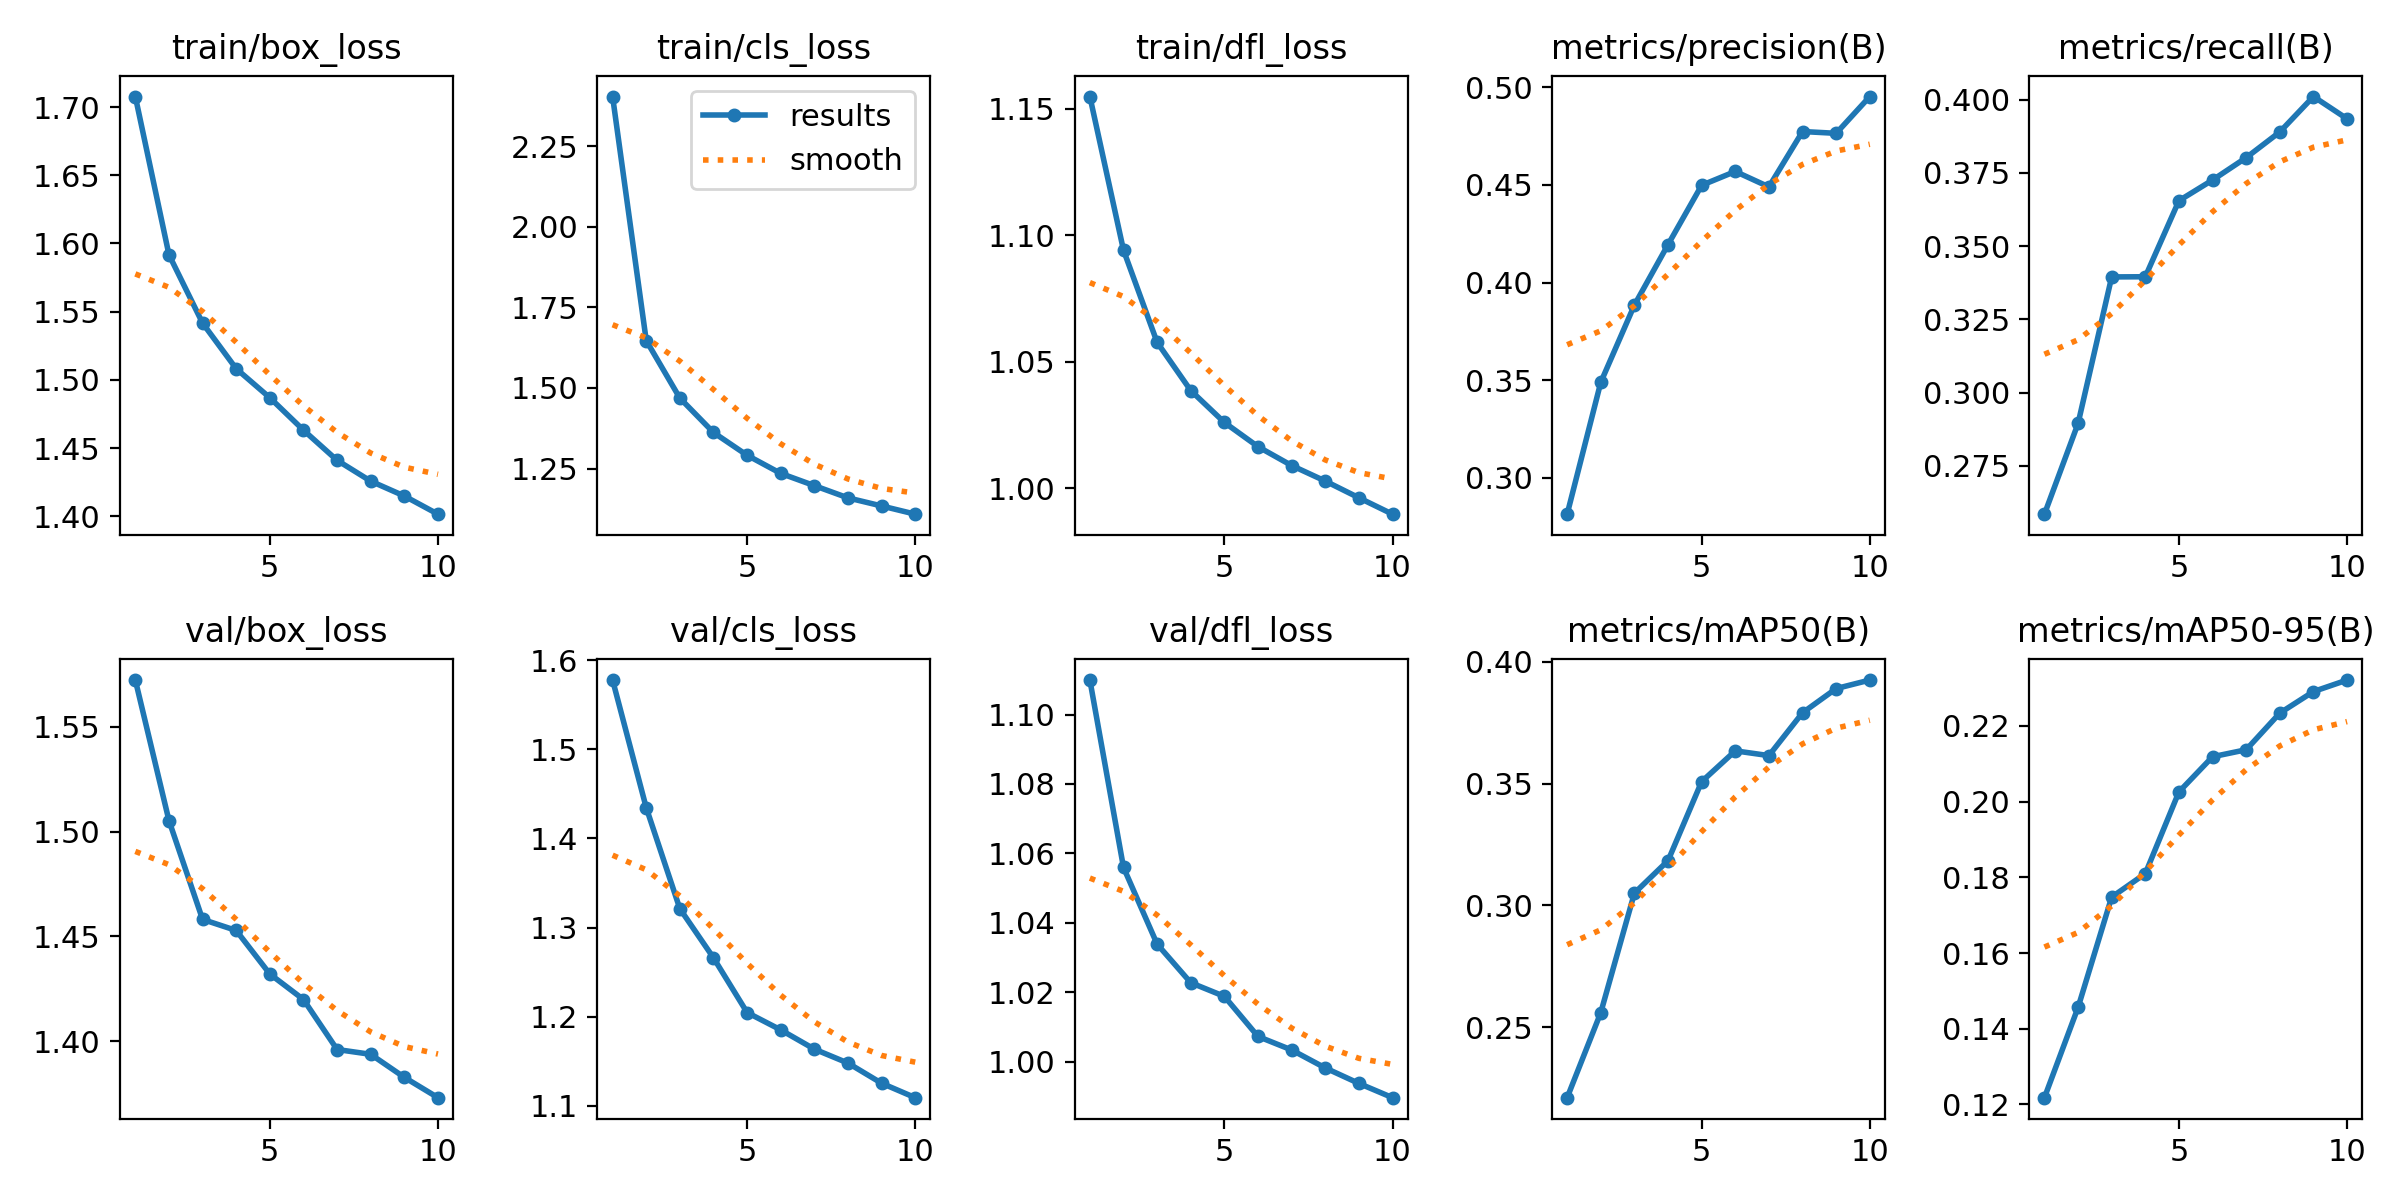

In [ ]:
from IPython.display import display, Image as IPImage

for exp in ["baseline_640", "highres_1280"]:
    plot_path = PROJECT_DIR / exp / "results.png"
    print(f"Training curve: {exp}")
    if plot_path.exists():
        display(IPImage(filename=str(plot_path)))
    else:
        print("results.png belum ditemukan.")


## Failure Cases

Paper menyatakan bahwa YOLO mengalami kesulitan dalam mendeteksi objek kecil yang muncul secara berkelompok. Oleh karena itu, failure cases dipilih dari citra dengan jumlah objek kecil yang tinggi dan prediksi yang masih tidak lengkap.

Notebook menampilkan contoh prediksi YOLO11n-640 dan YOLO11n-1280 untuk inspeksi visual. Contoh ini digunakan sebagai **qualitative evidence** untuk melihat keterbatasan deteksi objek kecil dan berkelompok.

Failure cases yang dipilih berdasarkan small-object miss:
0000295_02400_d_0000033.jpg | small GT = 280 | matched = 55 | missed = 225 | miss rate = 0.804
0000295_01800_d_0000030.jpg | small GT = 269 | matched = 49 | missed = 220 | miss rate = 0.818
0000295_02000_d_0000031.jpg | small GT = 261 | matched = 53 | missed = 208 | miss rate = 0.797


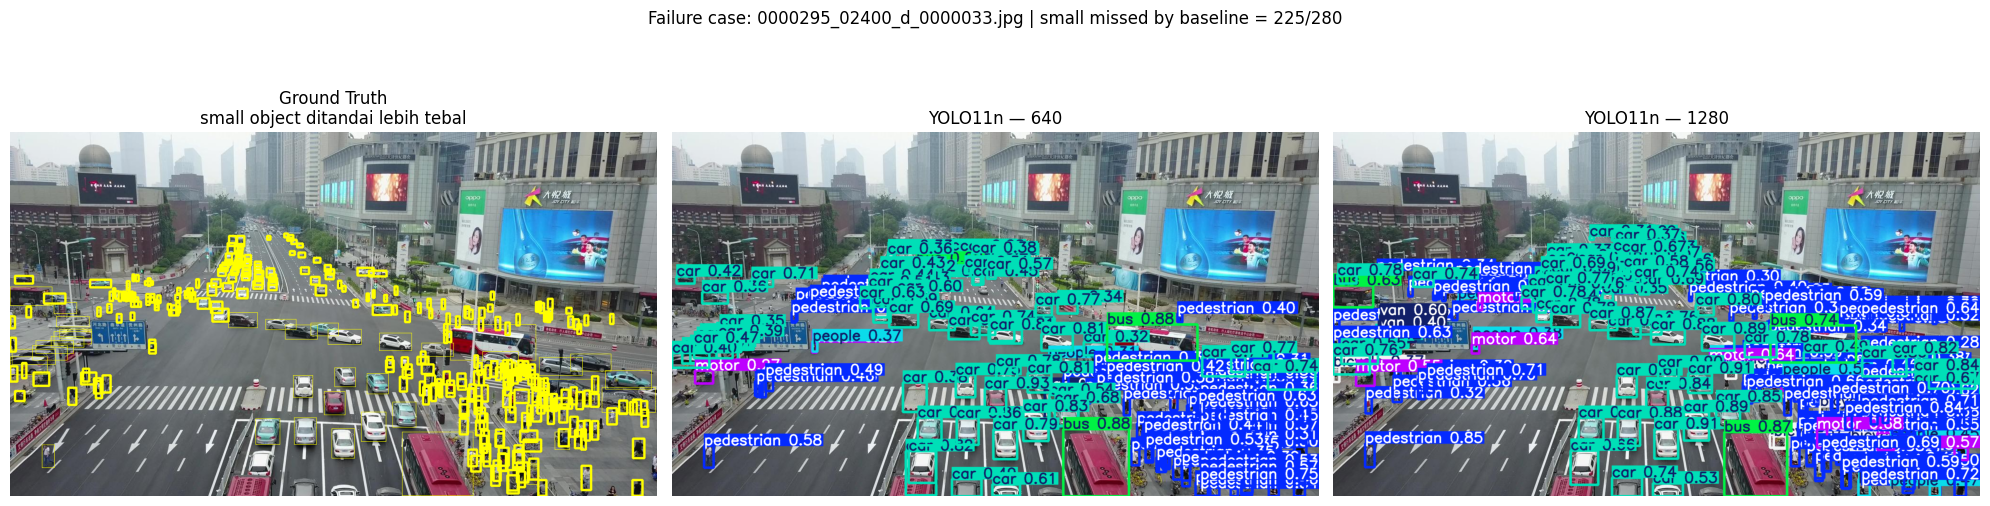

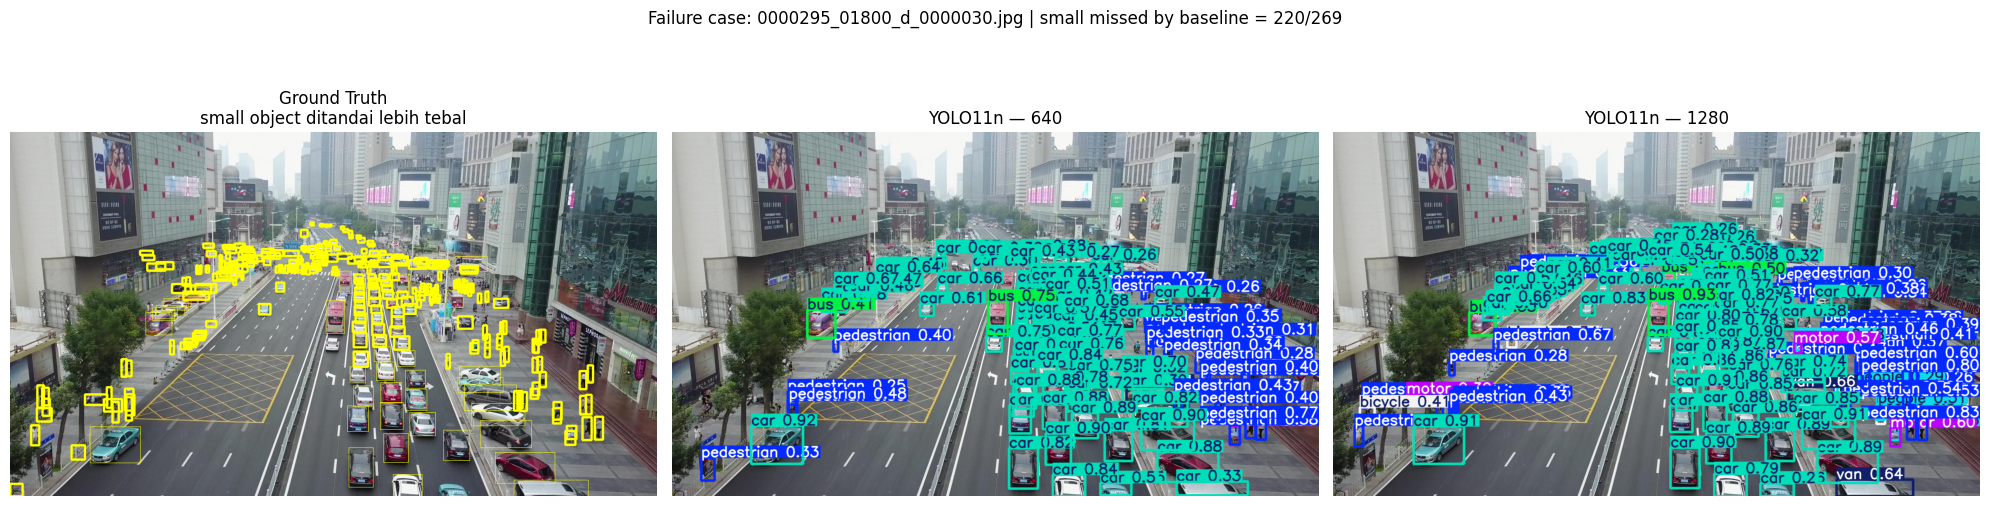

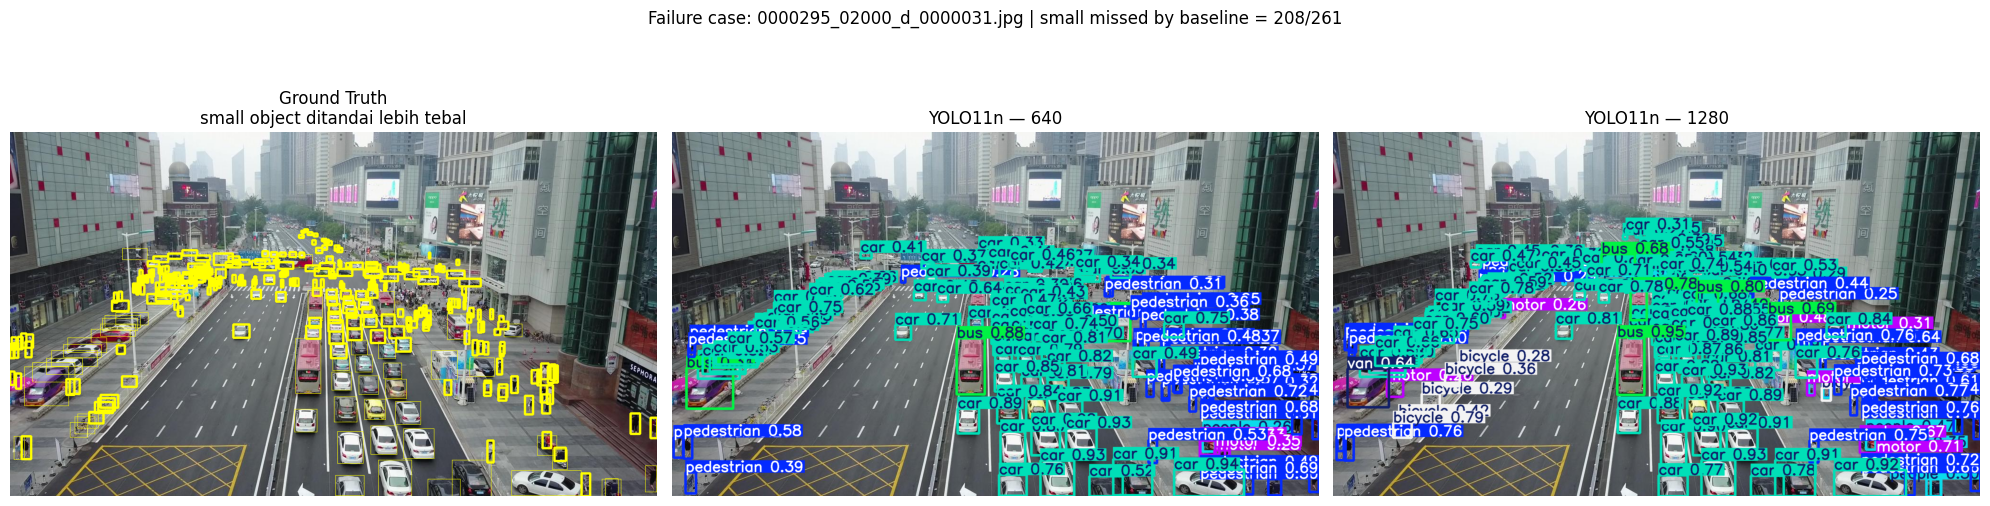

In [ ]:
from PIL import Image, ImageDraw

def load_gt_objects(img_path):
    img_path = Path(img_path)
    label_path = DATA_ROOT / "labels" / "val" / f"{img_path.stem}.txt"

    with Image.open(img_path) as im:
        W, H = im.size

    objects = []
    if not label_path.exists():
        return W, H, objects

    for line in label_path.read_text().splitlines():
        p = line.split()
        if len(p) != 5:
            continue

        cls, xc, yc, wn, hn = map(float, p)
        bw, bh = wn * W, hn * H
        x1 = (xc - wn/2) * W
        y1 = (yc - hn/2) * H
        x2 = (xc + wn/2) * W
        y2 = (yc + hn/2) * H

        objects.append({
            "cls": int(cls),
            "box": [x1, y1, x2, y2],
            "area": bw * bh,
            "small": (bw * bh) < (32 ** 2)
        })

    return W, H, objects

def iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)

    iw, ih = max(0.0, ix2-ix1), max(0.0, iy2-iy1)
    inter = iw * ih

    area_a = max(0.0, ax2-ax1) * max(0.0, ay2-ay1)
    area_b = max(0.0, bx2-bx1) * max(0.0, by2-by1)
    union = area_a + area_b - inter

    return inter / union if union > 0 else 0.0

def analyze_small_object_failures(model, image_paths, imgsz, max_candidates=3):
    candidates = []

    for img_path in image_paths:
        W, H, gt = load_gt_objects(img_path)
        small_gt = [g for g in gt if g["small"]]

        if not small_gt:
            continue

        result = model.predict(
            source=str(img_path),
            imgsz=imgsz,
            conf=0.25,
            iou=0.50,
            max_det=300,
            verbose=False
        )[0]

        preds = []
        if result.boxes is not None and len(result.boxes):
            boxes = result.boxes.xyxy.cpu().numpy()
            classes = result.boxes.cls.cpu().numpy().astype(int)
            scores = result.boxes.conf.cpu().numpy()

            for box, cls, score in zip(boxes, classes, scores):
                preds.append({
                    "cls": int(cls),
                    "box": box.tolist(),
                    "score": float(score)
                })

        unmatched = 0
        matched = 0

        for g in small_gt:
            best_iou = 0.0
            for p in preds:
                if p["cls"] != g["cls"]:
                    continue
                best_iou = max(best_iou, iou_xyxy(g["box"], p["box"]))

            if best_iou >= 0.50:
                matched += 1
            else:
                unmatched += 1

        candidates.append({
            "path": Path(img_path),
            "small_gt": len(small_gt),
            "small_matched": matched,
            "small_missed": unmatched,
            "miss_rate": unmatched / len(small_gt)
        })

    candidates.sort(
        key=lambda x: (x["small_missed"], x["miss_rate"], x["small_gt"]),
        reverse=True
    )
    return candidates[:max_candidates]

val_image_paths = sorted((DATA_ROOT / "images" / "val").glob("*.jpg"))

failure_search_images = val_image_paths
if FAST_MODE:
    failure_search_images = val_image_paths[:300]

failure_cases = analyze_small_object_failures(
    baseline_model,
    failure_search_images,
    IMG_BASELINE,
    max_candidates=3
)

print("Failure cases yang dipilih berdasarkan small-object miss:")
for item in failure_cases:
    print(
        item["path"].name,
        "| small GT =", item["small_gt"],
        "| matched =", item["small_matched"],
        "| missed =", item["small_missed"],
        "| miss rate =", round(item["miss_rate"], 3)
    )

def show_failure_comparison(item, baseline_model, highres_model):
    img_path = item["path"]

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Ground truth
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gt_vis = img.copy()

    _, _, gt_objects = load_gt_objects(img_path)
    for g in gt_objects:
        x1, y1, x2, y2 = map(int, g["box"])
        thickness = 3 if g["small"] else 1
        cv2.rectangle(gt_vis, (x1,y1), (x2,y2), (255,255,0), thickness)

    axes[0].imshow(gt_vis)
    axes[0].set_title("Ground Truth\nsmall object ditandai lebih tebal")
    axes[0].axis("off")

    # Baseline
    rb = baseline_model.predict(
        source=str(img_path), imgsz=IMG_BASELINE, conf=0.25, verbose=False
    )[0]
    bvis = cv2.cvtColor(rb.plot(), cv2.COLOR_BGR2RGB)
    axes[1].imshow(bvis)
    axes[1].set_title("YOLO11n — 640")
    axes[1].axis("off")

    # High resolution
    rh = highres_model.predict(
        source=str(img_path), imgsz=IMG_HIGHRES, conf=0.25, verbose=False
    )[0]
    hvis = cv2.cvtColor(rh.plot(), cv2.COLOR_BGR2RGB)
    axes[2].imshow(hvis)
    axes[2].set_title("YOLO11n — 1280")
    axes[2].axis("off")

    plt.suptitle(
        f"Failure case: {img_path.name} | "
        f"small missed by baseline = {item['small_missed']}/{item['small_gt']}"
    )
    plt.tight_layout()
    plt.show()

for item in failure_cases:
    show_failure_comparison(item, baseline_model, highres_model)

if not failure_cases:
    print("Tidak ditemukan small-object failure pada subset yang diperiksa.")
    print("Untuk analisis akhir, periksa kembali setelah FAST_MODE=False.")


## Analisis Hasil

### A. Apakah Keterbatasan Objek Kecil Masih Ada?

Hasil menunjukkan bahwa keterbatasan tersebut masih terlihat pada YOLO11n. Objek kecil secara konsisten memperoleh kinerja lebih rendah dibandingkan objek medium dan large. Pada 1280×1280, mAP@0.5:0.95 objek kecil sebesar 0.1237, dibandingkan 0.3308 untuk objek medium dan 0.4519 untuk objek large. Kasus kegagalan juga menunjukkan tingkat miss sebesar 0.797–0.818 pada citra yang sangat padat.

Hasil tersebut konsisten dengan paper YOLO asli yang secara eksplisit mengidentifikasi kesulitan pada objek kecil yang muncul secara berkelompok [4]. Namun, penelitian ini tidak menyatakan bahwa YOLO11n mereplikasi kinerja kuantitatif model asli. Arsitektur, dataset, prosedur pelatihan, dan pengaturan evaluasi berbeda. Kesimpulan yang tepat adalah bahwa jenis kesulitan yang sama masih dapat diamati pada model YOLO modern.

### B. Pengaruh Resolusi Input yang Lebih Tinggi

Intervensi resolusi tinggi secara jelas meningkatkan kinerja deteksi. mAP@0.5:0.95 keseluruhan meningkat dari 0.1279 menjadi 0.2277, sedangkan mAP@0.5:0.95 objek kecil meningkat dari 0.0451 menjadi 0.1237. Penjelasan yang didukung oleh rancangan eksperimen adalah bahwa resolusi input yang lebih tinggi mempertahankan lebih banyak informasi spasial pada objek kecil. Hasil menunjukkan bahwa intervensi mengurangi, tetapi tidak menghilangkan, keterbatasan tersebut.

### C. Citra Padat dan Kasus Kegagalan

Kasus kegagalan terpilih mengandung 261–280 objek ground truth kecil dengan tingkat miss mendekati 0,80. Kasus tersebut memberikan bukti langsung bahwa citra dengan kepadatan objek tinggi masih sulit dideteksi. Paper YOLO asli mengaitkan kesulitan objek berkelompok, antara lain, dengan keterbatasan spasial pada prediksi bounding box [4]. YOLO11n modern mengurangi kesulitan tersebut melalui perbaikan arsitektur, tetapi kasus kegagalan menunjukkan bahwa lokalisasi objek kecil pada citra padat tetap menantang.

### D. Perbandingan dengan Paper Asli

Paper YOLO melaporkan 57,9% mAP pada VOC 2012 test set [4]. Nilai tersebut tidak dapat dibandingkan secara langsung dengan mAP@0.5 sebesar 0.2287 dan 0.3792 pada penelitian ini karena dataset, jumlah kelas, versi model, prosedur pelatihan, dan pengaturan evaluasi berbeda. Perbandingan yang relevan untuk tugas ini bersifat kualitatif: paper asli mengidentifikasi objek kecil berkelompok sebagai kelemahan, sedangkan eksperimen ini menunjukkan bahwa objek kecil berkelompok tetap sulit dideteksi oleh YOLO11n pada VisDrone.

**Tabel 7. Perbandingan Kualitatif dengan YOLO Sebelumnya**

| Aspek | YOLO [4] | Penelitian Ini |
|---|---|---|
| Model | YOLO | YOLO11n |
| Dataset | PASCAL VOC | VisDrone2019-DET |
| Input | 448×448 pada sistem asli | 640×640 / 1280×1280 |
| Fokus | Deteksi objek umum | Objek kecil dan padat pada citra udara |
| Temuan | Objek kecil berkelompok sulit dideteksi | Kesulitan masih ada, berkurang pada 1280×1280 |

### E. Komputasi

Konfigurasi 1280×1280 membutuhkan komputasi yang jauh lebih besar. Waktu pelatihan meningkat dari 22,49 menjadi 60,64 menit, atau sekitar 2,7 kali lebih lama. Waktu validasi meningkat dari 0,326 menjadi 0,434 menit, sedangkan waktu prediksi meningkat dari sekitar 0,21 menjadi 0,27 menit. Oleh karena itu, resolusi tinggi bermanfaat ketika akurasi objek kecil diprioritaskan, tetapi menghasilkan biaya komputasi yang tinggi.

### F. Keterbatasan Evaluasi

Validasi menunjukkan bahwa beberapa citra validasi memiliki hingga 317 objek. Oleh karena itu, konfigurasi validasi menggunakan `max_det=317`, bukan nilai default 300. Hal ini penting pada citra padat karena batas deteksi yang terlalu rendah dapat membatasi recall. Kondisi tersebut diperlakukan sebagai keterbatasan eksperimen, bukan sebagai bukti bahwa eksperimen tidak valid.

Evaluasi berdasarkan ukuran objek menggunakan prosedur kategori area COCO yang terpisah dari validasi utama Ultralytics. Kedua keluaran tersebut karena itu dilaporkan secara terpisah. Selain itu, hanya dua resolusi input dan sepuluh epoch yang dievaluasi sehingga penelitian ini belum dapat menentukan resolusi atau durasi pelatihan yang optimal.

## 19. Kesimpulan

Penelitian ini menguji apakah keterbatasan deteksi objek kecil yang dilaporkan pada paper YOLO asli masih terdapat pada YOLO11n dan apakah peningkatan resolusi input dapat meningkatkan deteksi pada VisDrone2019-DET. Hasil eksperimen menunjukkan bahwa keterbatasan tersebut masih terlihat. Objek kecil memperoleh kinerja lebih rendah dibandingkan objek medium dan large, sedangkan kasus kegagalan pada citra padat menunjukkan tingkat miss sebesar 0.797–0.818.

Peningkatan resolusi dari 640×640 menjadi 1280×1280 secara substansial meningkatkan kinerja deteksi. mAP@0.5 meningkat dari **0.2287 menjadi 0.3792**, sedangkan mAP@0.5:0.95 meningkat dari **0.1279 menjadi 0.2277**. Pada objek small, mAP@0.5:0.95 meningkat dari **0.0451 menjadi 0.1237**. Dengan demikian, resolusi yang lebih tinggi membantu mengurangi keterbatasan deteksi objek kecil, tetapi tidak menghilangkannya secara keseluruhan.

Peningkatan performa tersebut disertai peningkatan biaya komputasi. Waktu pelatihan meningkat dari **22.49 menit menjadi 60.64 menit**, atau sekitar **2.7 kali lebih lama**. Waktu validasi meningkat dari **0.326 menjadi 0.434 menit**, sedangkan waktu prediksi meningkat dari sekitar **0.21 menjadi 0.27 menit**. Oleh karena itu, penggunaan resolusi 1280×1280 lebih sesuai ketika peningkatan kemampuan mendeteksi objek kecil menjadi prioritas, dengan konsekuensi kebutuhan komputasi yang lebih tinggi.



In [ ]:
final_summary = pd.DataFrame([
    {
        "experiment": "YOLO11n-640",
        "imgsz": IMG_BASELINE,
        "epochs": EPOCHS,
        "fraction": FRACTION,
        "mAP@0.5": baseline_map50,
        "mAP@0.5:0.95": baseline_map5095,
        "training_time_min": baseline_train_time/60,
        "validation_time_min": baseline_val_time/60,
    },
    {
        "experiment": "YOLO11n-1280",
        "imgsz": IMG_HIGHRES,
        "epochs": EPOCHS,
        "fraction": FRACTION,
        "mAP@0.5": highres_map50,
        "mAP@0.5:0.95": highres_map5095,
        "training_time_min": highres_train_time/60,
        "validation_time_min": highres_val_time/60,
    }
])

display(final_summary.round(4))

print("=== Size-wise mAP@0.5 ===")
display(size_map_df.round(4))

print("=== Size-wise mAP@0.5:0.95 ===")
display(size_map_5095_df.round(4))

# Simpan semua angka utama.
final_summary.to_csv(PROJECT_DIR / "main_results.csv", index=False)
size_map_df.to_csv(PROJECT_DIR / "size_map50.csv", index=False)
size_map_5095_df.to_csv(PROJECT_DIR / "size_map5095.csv", index=False)

metadata = pd.DataFrame([{
    "seed": SEED,
    "model": MODEL_NAME,
    "fast_mode": FAST_MODE,
    "epochs": EPOCHS,
    "fraction": FRACTION,
    "baseline_imgsz": IMG_BASELINE,
    "highres_imgsz": IMG_HIGHRES,
    "dataset": "VisDrone2019-DET",
    "claim_tested": "Keterbatasan YOLO pada small objects yang berkelompok"
}])
metadata.to_csv(PROJECT_DIR / "experiment_metadata.csv", index=False)

print("\nFile hasil:")
for p in sorted(PROJECT_DIR.glob("*.csv")):
    print(" -", p)


,experiment,imgsz,epochs,fraction,mAP@0.5,mAP@0.5:0.95,training_time_min,validation_time_min
0,YOLO11n-640,640,10,1.0,0.2287,0.1279,22.4939,0.3258
1,YOLO11n-1280,1280,10,1.0,0.3792,0.2277,60.6394,0.4340


=== Size-wise mAP@0.5 ===


,experiment,mAP@0.5,small,medium,large
0,YOLO11n-640,0.2031,0.1082,0.3264,0.463
1,YOLO11n-1280,0.3552,0.2490,0.5130,0.571


=== Size-wise mAP@0.5:0.95 ===


,experiment,mAP@0.5:0.95,small,medium,large
0,YOLO11n-640,0.1176,0.0451,0.1911,0.3544
1,YOLO11n-1280,0.2155,0.1237,0.3308,0.4519



File hasil:
 - /content/yolo_visdrone_experiment/experiment_metadata.csv
 - /content/yolo_visdrone_experiment/main_results.csv
 - /content/yolo_visdrone_experiment/size_map50.csv
 - /content/yolo_visdrone_experiment/size_map5095.csv


## Referensi

[1] R. Girshick, “Fast R-CNN,” in Proc. IEEE Int. Conf. Computer Vision (ICCV), 2015, pp. 1440–1448.

[2] S. Ren, K. He, R. Girshick, and J. Sun, “Faster R-CNN: Towards real-time object detection with region proposal networks,” in Advances in Neural Information Processing Systems (NeurIPS), vol. 28, 2015, pp. 91–99.

[3] W. Liu, D. Anguelov, D. Erhan, C. Szegedy, S. Reed, C.-Y. Fu, and A. C. Berg, “SSD: Single shot MultiBox detector,” in Computer Vision – ECCV 2016, 2016, pp. 21–37.

[4] J. Redmon, S. Divvala, R. Girshick, and A. Farhadi, “You only look once: Unified, real-time object detection,” in Proc. IEEE Conf. Computer Vision and Pattern Recognition (CVPR), 2016, pp. 779–788.

[5] P. Zhu, L. Wen, D. Du, X. Bian, H. Ling, Q. Hu, Q. Nie, H. Cheng, C. Liu, X. Liu, W. Ma, H. Wu, L. Wang, A. Schumann, et al., “VisDrone-DET2018: The vision meets drone object detection in image challenge results,” in Proc. European Conf. Computer Vision (ECCV) Workshops, 2018, pp. 437–468.

[6] T.-Y. Lin, P. Dollár, R. Girshick, K. He, B. Hariharan, and S. Belongie, “Feature pyramid networks for object detection,” in Proc. IEEE Conf. Computer Vision and Pattern Recognition (CVPR), 2017, pp. 2117–2125.

[7] G. Jocher and J. Qiu, “Ultralytics YOLO11,” Ultralytics, version 11.0.0, 2024. [Online]. Available: https://github.com/ultralytics/ultralytics.

[8] T.-Y. Lin, M. Maire, S. Belongie, J. Hays, P. Perona, D. Ramanan, P. Dollár, and C. L. Zitnick, “Microsoft COCO: Common objects in context,” in Computer Vision – ECCV 2014, 2014, pp. 740–755.